# EDA IMAGE - NEW PLANT DISEASES DATASET

Mục tiêu:
- Hiểu cấu trúc và phân bố dữ liệu
- Xác định đặc trưng hình ảnh quan trọng
- Phát hiện vấn đề tiềm ẩn (bias, imbalance, noise)
- Định hướng tiền xử lý và xây dựng mô hình

Nội dung:
- [0. Tổng quan dữ liệu](#0-tổng-quan-dữ-liệu)
- [1. Import thư viện và cấu hình](#1-import-thư-viện-và-cấu-hình)
- [2. Tải dữ liệu và thống kê tổng quan](#2-tải-dữ-liệu-và-thống-kê-tổng-quan)
- [3. Phân phối pixel theo kênh màu](#3-phân-phối-pixel-theo-kênh-màu-histogram--kde)
- [4. Phân tích mất cân bằng lớp](#4-phân-tích-mất-cân-bằng-lớp-class-imbalance)
- [5. Phát hiện trùng lặp](#5-phát-hiện-ảnh-trùng-lặp-perceptual-hash---phash)
- [6. Phân tích độ tương phản và độ sáng](#6-phân-tích-độ-tương-phản-và-độ-sáng-brightness--contrast-analysis)
- [7. Tổng kết](#7-tổng-kết-và-khuyến-nghị)


## 0. Tổng quan dữ liệu:

### Chủ đề dữ liệu:

Bộ dữ liệu phục vụ bài toán phân loại bệnh cây trồng dựa trên ảnh lá (image classification) trong lĩnh vực Computer Vision và Nông nghiệp thông minh.
- **Đơn vị dữ liệu:** Ảnh RGB của lá cây
- **Label:** (Plant + Disease)
- **Bài toán:** Multi-class classification

Dataset mô tả các biểu hiện bệnh lý trên lá:
- Đốm (spots)
- Cháy lá (blight)
- Nhiễm nấm / vi khuẩn / virus

→ Mục tiêu: tự động chẩn đoán bệnh cây từ hình ảnh.
### Nguồn dữ liệu:
- **Nền tảng:** Kaggle
- **Tên bộ dữ liệu:** New Plant Diseases Dataset
- **URL:** [https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset](https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset)
- **Tác giả:** Samir Bhattarai
- **Nguồn công bố:** dữ liệu gốc được trích xuất từ dự án PlantVillage (Đại học Penn State, do David Hughes và Marcel Salathé khởi xướng và công bố).
- **Năm cập nhật:** 2019


### Lý do chọn dataset:
- Phù hợp với yêu cầu đồ án


## 0. Phân tích thống kê tập dữ liệu
### Tổng quan
Tập dữ liệu này bao gồm các hình ảnh lá cà chua được thu thập nhằm phục vụ bài toán phân loại bệnh cây trồng. Mỗi ảnh được gán nhãn tương ứng với tình trạng của lá, bao gồm các lớp bệnh khác nhau và lớp lá khỏe mạnh.  
Tập dữ liệu bao gồm:
- **images**: Các ảnh RGB của lá cà chua.
- **class_folders**: Gồm 5 lớp, bao gồm healthy và 4 loại bệnh.
    - Tomato___healthy
    - Tomato___Leaf_Mold
    - Tomato___Late_blight
    - Tomato___Early_blight
    - Tomato___Bacterial_spot
- **labels.csv**: Tệp chứa thông tin ánh xạ giữa tên ảnh và nhãn tương ứng. File này cho phép liên kết các ảnh trong thư mục `images/` với nhãn phân loại, phục vụ cho việc huấn luyện và phân tích dữ liệu.

Phân bố dữ liệu giữa các lớp tương đối đồng đều, giúp hạn chế vấn đề mất cân bằng lớp trong quá trình huấn luyện. Ngoài ra, các ảnh có sự đa dạng về điều kiện ánh sáng, màu sắc và hình dạng lá, phản ánh tính thực tế của dữ liệu.
### Nội dung thực hiện
1. Phân phối giá trị pixel toàn tập theo từng kênh màu (Histogram + KDE)
2. Phân tích mất cân bằng lớp (Class Imbalance)
3. Phát hiện ảnh trùng / gần trùng bằng **perceptual hash (pHash)**
4. Phân tích **độ sáng** và **độ tương phản** toàn cục theo từng lớp bằng **mean intensity** và **standard deviation**.
### Import thư viện

## 1. Import thư viện và cấu hình

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import os
from pathlib import Path
import time
warnings.filterwarnings('ignore')

# Import thư viện xử lý ảnh
from PIL import Image
import cv2

# Import thư viện thống kê
from scipy import stats
from scipy.stats import skew, kurtosis
from sklearn.neighbors import NearestNeighbors

# Import thư viện cho DCT (Discrete Cosine Transform) cho pHash
from scipy.fftpack import dct

# Cấu hình hiển thị
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Cấu hình pandas
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print("Các thư viện đã được import thành công!")

Các thư viện đã được import thành công!


## 2. Tải dữ liệu và thống kê tổng quan

In [ ]:
# Đường dẫn dữ liệu
DATA_DIR = Path('../data/raw/lab_2.1_NewPlantDiseasesDataset')
IMAGES_DIR = DATA_DIR / 'images'
LABELS_PATH = DATA_DIR / 'labels.csv'
PROCESSED_DIR = Path('../data/processed/processed_image')

# Tải file labels
df_labels = pd.read_csv(LABELS_PATH)

# Hiển thị thông tin cơ bản
print(f"Tổng số ảnh: {len(df_labels)}")
print(f"\nCác cột trong dataset: {df_labels.columns.tolist()}")
print(f"\nSố lớp: {df_labels['label'].nunique()}")
print(f"Danh sách các lớp: {df_labels['label'].unique().tolist()}")
print(f"\n{'='*80}")
print("5 mẫu đầu tiên:")
df_labels.head()

Tổng số ảnh: 6000

Các cột trong dataset: ['image', 'label', 'original_image']

Số lớp: 5
Danh sách các lớp: ['Tomato___Bacterial_spot', 'Tomato___healthy', 'Tomato___Leaf_Mold', 'Tomato___Early_blight', 'Tomato___Late_blight']

5 mẫu đầu tiên:


,image,label,original_image
0,img_00001.jpg,Tomato___Bacterial_spot,bcffc5ba-6602-455f-a84c-eb0ad85672bc___UF.GRC_...
1,img_00002.jpg,Tomato___Bacterial_spot,2f3e2c44-a83b-4f72-a831-ac42aec1020e___UF.GRC_...
2,img_00003.jpg,Tomato___healthy,0c4b06d5-4053-44fc-99b6-504934fdd3a9___GH_HL L...
3,img_00004.jpg,Tomato___Leaf_Mold,ebe5c5c5-7e29-4aa7-bc0b-f895b5bc3d20___Crnl_L....
4,img_00005.jpg,Tomato___Leaf_Mold,bc374eed-3802-4ffe-9339-47e04a74a648___Crnl_L....


## 3. Phân phối Pixel theo kênh màu (Histogram & KDE)

### Mục tiêu
- Histogram cho biết phân phối tần suất mức cường độ pixel.
- KDE (Kernel Density Estimation) cho biết dạng phân phối được làm mượt.
- Cần thực hiện **theo từng kênh màu** trên **toàn bộ tập dữ liệu**.
### Phương pháp
- Đọc ảnh và chuyển tất cả về **RGB**
- Gom toàn bộ pixel của từng kênh **R, G, B**
- Vẽ:
  - Histogram mật độ
  - KDE mật độ
- Đồng thời lưu các thống kê số:
  - mean, std, min, max, median, quantiles

**Histogram**: Biểu đồ tần suất của giá trị pixel (0-255) cho mỗi kênh màu RGB. Với một ảnh có $N$ pixels, histogram được tính bằng cách đếm tần suất xuất hiện của mỗi giá trị intensity:

$$h(i) = \frac{1}{N} \sum_{p=1}^{N} \mathbb{1}[I(p) = i], \quad i \in [0, 255]$$

**Kernel Density Estimation (KDE)**: Ước lượng mật độ xác suất liên tục từ dữ liệu rời rạc. KDE sử dụng Gaussian kernel:

$$\hat{f}(x) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

trong đó $K(u) = \frac{1}{\sqrt{2\pi}}e^{-\frac{u^2}{2}}$ là Gaussian kernel và $h$ là bandwidth.

**Silverman's Rule of Thumb** cho bandwidth tối ưu:

$$h = 0.9 \cdot \min\left(\hat{\sigma}, \frac{IQR}{1.34}\right) \cdot n^{-1/5}$$

với $\hat{\sigma}$ là độ lệch chuẩn mẫu, $IQR$ là khoảng tứ phân vị, $n$ là số lượng mẫu.

**Lưu ý kỹ thuật**:
- Sử dụng batch processing để tránh Out-Of-Memory với dataset lớn
- Log-scale trên trục y để quan sát rõ phân phối (vì pixel nền thường tạo spike lớn)

In [3]:
# =========================
# Pixel distribution theo từng kênh màu
# =========================
MAX_IMAGES_FOR_PIXEL_ANALYSIS = None
PIXELS_PER_IMAGE_FOR_ANALYSIS = 5000  

selected_df = df_labels if MAX_IMAGES_FOR_PIXEL_ANALYSIS is None else df_labels.head(MAX_IMAGES_FOR_PIXEL_ANALYSIS)

channel_values = {"R": [], "G": [], "B": []}
rng = np.random.default_rng(42)

for img_name in selected_df["image"]:
    img_path = IMAGES_DIR / img_name
    
    with Image.open(img_path) as img:
        arr = np.array(img.convert("RGB"), dtype=np.uint8).reshape(-1, 3)

    sample_size = min(PIXELS_PER_IMAGE_FOR_ANALYSIS, len(arr))
    idx = rng.choice(len(arr), size=sample_size, replace=False)
    sampled = arr[idx]

    channel_values["R"].append(sampled[:, 0])
    channel_values["G"].append(sampled[:, 1])
    channel_values["B"].append(sampled[:, 2])

for ch in channel_values:
    channel_values[ch] = np.concatenate(channel_values[ch])

pixel_distribution_stats = {}
for ch, vals in channel_values.items():
    pixel_distribution_stats[ch] = {
        "n_pixels": int(vals.size),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "min": int(np.min(vals)),
        "q25": float(np.quantile(vals, 0.25)),
        "median": float(np.median(vals)),
        "q75": float(np.quantile(vals, 0.75)),
        "max": int(np.max(vals)),
    }

pixel_distribution_df = pd.DataFrame(pixel_distribution_stats).T
pixel_distribution_df

,n_pixels,mean,std,min,q25,median,q75,max
R,3.0000e+07,112.0296,50.6552,0.0,76.0,116.0,147.0,255.0
G,3.0000e+07,116.2181,46.0328,0.0,89.0,119.0,144.0,255.0
B,3.0000e+07,106.1197,53.2177,0.0,66.0,111.0,144.0,255.0


In [4]:
# Hàm tính histogram với batch processing
def compute_histogram_batch(df, images_dir, batch_size=1000):
    """
    Tính histogram cho toàn bộ dataset theo batch để tránh OOM

    Parameters:
    - df: DataFrame chứa thông tin ảnh
    - images_dir: Thư mục chứa ảnh
    - batch_size: Số ảnh xử lý mỗi lần

    Returns:
    - hist_r, hist_g, hist_b: Histogram tích lũy cho 3 kênh màu
    - total_pixels: Tổng số pixel đã xử lý
    """
    # Khởi tạo histogram cho 3 kênh (256 bins từ 0-255)
    hist_r = np.zeros(256, dtype=np.int64)
    hist_g = np.zeros(256, dtype=np.int64)
    hist_b = np.zeros(256, dtype=np.int64)
    total_pixels = 0

    # Xử lý theo batch
    n_images = len(df)
    n_batches = (n_images + batch_size - 1) // batch_size

    print(f"Đang xử lý {n_images} ảnh theo {n_batches} batches...")

    for batch_idx in range(n_batches):
        start_idx = batch_idx * batch_size
        end_idx = min((batch_idx + 1) * batch_size, n_images)
        batch_df = df.iloc[start_idx:end_idx]

        for idx, row in batch_df.iterrows():
            img_path = images_dir / row['image']
            try:
                # Dùng .convert("RGB") của bài 2 để ép mọi ảnh về 3 kênh
                img = Image.open(img_path).convert("RGB")
                img_array = np.array(img)

                r_channel = img_array[:, :, 0].flatten()
                g_channel = img_array[:, :, 1].flatten()
                b_channel = img_array[:, :, 2].flatten()

                hist_r += np.bincount(r_channel, minlength=256)
                hist_g += np.bincount(g_channel, minlength=256)
                hist_b += np.bincount(b_channel, minlength=256)
                
                total_pixels += r_channel.size
                    
            except Exception as e:
                print(f"Lỗi khi đọc {img_path}: {e}")
                continue

        if (batch_idx + 1) % 5 == 0:
            print(f"  Đã xử lý batch {batch_idx + 1}/{n_batches}")

    print(f"Hoàn thành! Tổng số pixel: {total_pixels:,}")
    return hist_r, hist_g, hist_b, total_pixels

# Tính histogram
hist_r, hist_g, hist_b, total_pixels = compute_histogram_batch(df_labels, IMAGES_DIR, batch_size=1000)

Đang xử lý 6000 ảnh theo 6 batches...
  Đã xử lý batch 5/6
Hoàn thành! Tổng số pixel: 393,216,000


In [5]:
# Chuẩn hóa histogram thành xác suất
hist_r_norm = hist_r / total_pixels
hist_g_norm = hist_g / total_pixels
hist_b_norm = hist_b / total_pixels

print("Đã chuẩn hóa histogram thành phân phối xác suất")
print(f"Tổng xác suất kênh R: {hist_r_norm.sum():.6f}")
print(f"Tổng xác suất kênh G: {hist_g_norm.sum():.6f}")
print(f"Tổng xác suất kênh B: {hist_b_norm.sum():.6f}")

Đã chuẩn hóa histogram thành phân phối xác suất
Tổng xác suất kênh R: 1.000000
Tổng xác suất kênh G: 1.000000
Tổng xác suất kênh B: 1.000000


In [6]:
# Sub-sampling pixel để tính KDE 
def sample_pixels_for_kde(df, images_dir, sample_ratio=1, max_samples=10000000000):
    """
    Lấy mẫu ngẫu nhiên pixel từ dataset để tính KDE

    Parameters:
    - df: DataFrame chứa thông tin ảnh
    - images_dir: Thư mục chứa ảnh
    - sample_ratio: Tỉ lệ pixel lấy mẫu từ mỗi ảnh
    - max_samples: Số lượng mẫu tối đa cho mỗi kênh

    Returns:
    - samples_r, samples_g, samples_b: Mảng pixel mẫu cho 3 kênh
    """
    samples_r = []
    samples_g = []
    samples_b = []

    print(f"Đang lấy mẫu {sample_ratio*100}% pixel từ các ảnh...")

    # Lấy mẫu từ một số ảnh ngẫu nhiên
    sample_images = df.sample(min(500, len(df)), random_state=42)

    for idx, row in sample_images.iterrows():
        img_path = images_dir / row['image']
        try:
            img = Image.open(img_path)
            img_array = np.array(img)

            if len(img_array.shape) == 3 and img_array.shape[2] == 3:
                # Lấy mẫu ngẫu nhiên từ ảnh
                total_pixels_img = img_array.shape[0] * img_array.shape[1]
                n_samples = int(total_pixels_img * sample_ratio)

                # Random sampling
                flat_r = img_array[:, :, 0].flatten()
                flat_g = img_array[:, :, 1].flatten()
                flat_b = img_array[:, :, 2].flatten()

                indices = np.random.choice(total_pixels_img, n_samples, replace=False)

                samples_r.extend(flat_r[indices])
                samples_g.extend(flat_g[indices])
                samples_b.extend(flat_b[indices])

                # Kiểm tra nếu đã đủ mẫu
                if len(samples_r) >= max_samples:
                    break
        except:
            continue

    samples_r = np.array(samples_r[:max_samples])
    samples_g = np.array(samples_g[:max_samples])
    samples_b = np.array(samples_b[:max_samples])

    print(f"Đã lấy {len(samples_r):,} mẫu pixel cho mỗi kênh màu")
    return samples_r, samples_g, samples_b

# Lấy mẫu pixel
samples_r, samples_g, samples_b = sample_pixels_for_kde(df_labels, IMAGES_DIR)

Đang lấy mẫu 100% pixel từ các ảnh...
Đã lấy 32,768,000 mẫu pixel cho mỗi kênh màu


In [7]:
# Hàm tính bandwidth theo Silverman's Rule of Thumb
def silverman_bandwidth(data):
    """
    Tính bandwidth tối ưu theo công thức Silverman
    h = 0.9 * min(std, IQR/1.34) * n^(-1/5)
    """
    n = len(data)
    sigma = np.std(data)
    q75, q25 = np.percentile(data, [75, 25])
    iqr = q75 - q25

    h = 0.9 * min(sigma, iqr / 1.34) * (n ** (-1/5))

    return h

# Tính bandwidth cho mỗi kênh
bandwidth_r = silverman_bandwidth(samples_r)
bandwidth_g = silverman_bandwidth(samples_g)
bandwidth_b = silverman_bandwidth(samples_b)

print("Bandwidth tính theo Silverman's Rule:")
print(f"  Kênh R: {bandwidth_r:.4f}")
print(f"  Kênh G: {bandwidth_g:.4f}")
print(f"  Kênh B: {bandwidth_b:.4f}")

Bandwidth tính theo Silverman's Rule:
  Kênh R: 1.4302
  Kênh G: 1.1599
  Kênh B: 1.5011


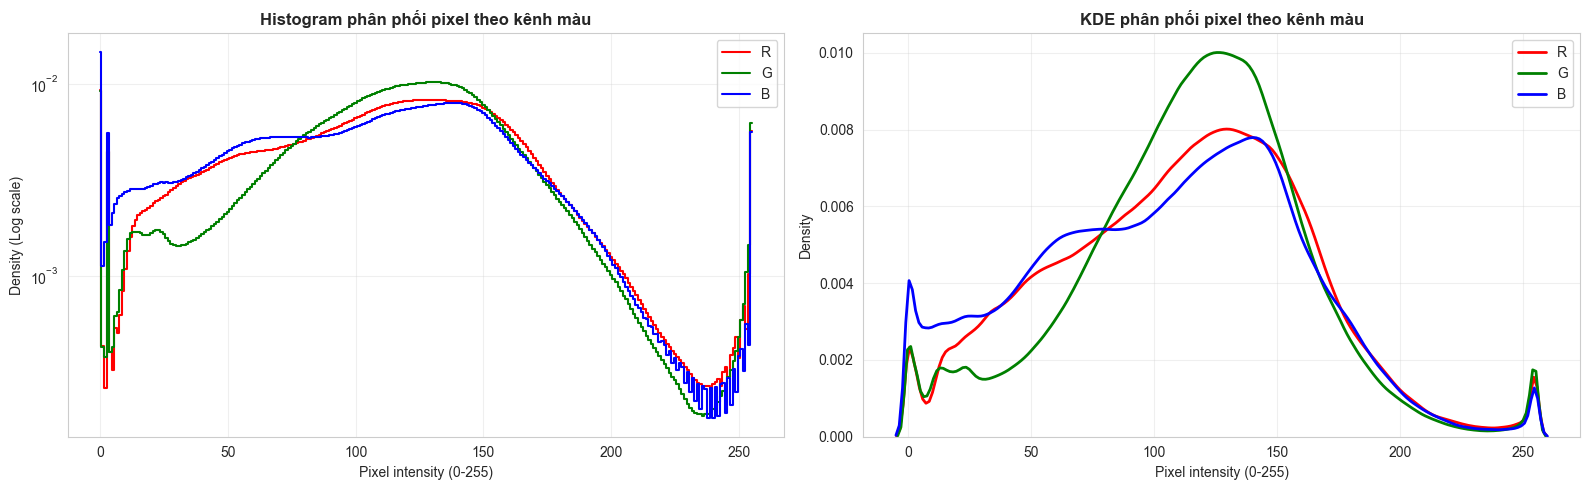

Biểu đồ đã được lưu tại: ../data/processed/pixel_distribution_combined.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x_range = np.arange(256)

# ==========================================
# Cột 1: Histogram 
# ==========================================
axes[0].step(x_range, hist_r_norm, color='red', label='R', where='mid', linewidth=1.5)
axes[0].step(x_range, hist_g_norm, color='green', label='G', where='mid', linewidth=1.5)
axes[0].step(x_range, hist_b_norm, color='blue', label='B', where='mid', linewidth=1.5)

axes[0].set_title("Histogram phân phối pixel theo kênh màu", fontweight='bold')
axes[0].set_xlabel("Pixel intensity (0-255)")
axes[0].set_ylabel("Density (Log scale)")
axes[0].set_yscale('log') 
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ==========================================
# Cột 2: KDE Plot 
# ==========================================
sns.kdeplot(samples_r, ax=axes[1], label="R", color="red", fill=False, linewidth=2)
sns.kdeplot(samples_g, ax=axes[1], label="G", color="green", fill=False, linewidth=2)
sns.kdeplot(samples_b, ax=axes[1], label="B", color="blue", fill=False, linewidth=2)

axes[1].set_title("KDE phân phối pixel theo kênh màu", fontweight='bold')
axes[1].set_xlabel("Pixel intensity (0-255)")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/processed_image/pixel_distribution_combined.png', dpi=150)
plt.show()

print("Biểu đồ đã được lưu tại: ../data/processed/processed_image/pixel_distribution_combined.png")

In [9]:
# Tính các moment thống kê và tứ phân vị
def compute_distribution_stats(samples, channel_name):
    """
    Tính các thống kê mô tả phân phối chi tiết
    """
    return {
        'channel': channel_name,
        'mean': np.mean(samples),
        'std': np.std(samples),
        'skewness': skew(samples),
        'kurtosis': kurtosis(samples),
        'min': np.min(samples),
        'q25': np.percentile(samples, 25),
        'median': np.median(samples),
        'q75': np.percentile(samples, 75),
        'max': np.max(samples)
    }

# Tính thống kê cho 3 kênh (Giữ nguyên)
stats_r = compute_distribution_stats(samples_r, 'Red')
stats_g = compute_distribution_stats(samples_g, 'Green')
stats_b = compute_distribution_stats(samples_b, 'Blue')

# Tạo DataFrame thống kê
df_stats = pd.DataFrame([stats_r, stats_g, stats_b])
print("Thống kê phân phối pixel theo kênh màu:")
print("="*100)
print(df_stats.to_string(index=False))

Thống kê phân phối pixel theo kênh màu:
channel     mean     std  skewness  kurtosis  min  q25  median   q75  max
    Red 111.0970 50.6112   -0.0080   -0.2848    0 75.0   115.0 147.0  255
  Green 115.3861 45.7053   -0.1355    0.4567    0 89.0   119.0 144.0  255
   Blue 105.6894 53.1213   -0.0254   -0.4898    0 66.0   110.0 144.0  255


## **Phân tích kết quả phân phối pixel**

### **Nhận xét về histogram:**

* Phân phối giá trị pixel trên toàn bộ dataset tương đối ổn định và không có sự lệch mạnh, dữ liệu có xu hướng tập trung chủ yếu ở vùng **cường độ trung bình (mid-intensity range)**, khoảng từ 80 đến 160.
* Kênh **Green có giá trị trung bình cao nhất**, phản ánh đặc trưng tự nhiên của ảnh lá cây (màu xanh chiếm ưu thế), tiếp theo là kênh R (Red) và thấp nhất là kênh B (Blue).
* Kênh **Blue có độ phân tán lớn nhất (std cao nhất)**, cho thấy sự biến thiên mạnh hơn, có thể do ảnh hưởng của ánh sáng hoặc nền, tiếp theo là R , thấp nhất là G với kênh G là ổn định hơn.
* Các đỉnh (peaks) trong histogram thể hiện các màu sắc phổ biến như xanh lá, nền sáng hoặc vùng bệnh.
* Cả ba kênh đều có dạng phân phối **lệch nhẹ về phía vùng sáng**, với đỉnh chính nằm khoảng **120-140**.
* Phân phối của các kênh tương đối giống nhau, tuy nhiên:
    - Kênh G có đỉnh cao hơn → tập trung mật độ nhiều hơn ở vùng trung bình
    - Kênh B có phần phân phối trải rộng hơn ở vùng thấp (0-80)
* Ngoài ra, sự xuất hiện của giá trị min = 0 và max = 255 ở cả ba kênh cho thấy dữ liệu bao phủ toàn bộ dải dynamic range, tuy nhiên mật độ ở hai đầu này rất thấp. 

### **Nhận xét về Skewness:**

* Giá trị skewness của cả ba kênh đều **gần bằng 0**:

  * Red ≈ -0.008
  * Green ≈ -0.1355
  * Blue ≈ -0.0254

* Điều này cho thấy phân phối pixel **gần đối xứng (Gaussian-like)**, không bị lệch đáng kể về phía giá trị cao hoặc thấp.

* Kênh Blue có skewness dương nhẹ, cho thấy có xu hướng xuất hiện nhiều pixel sáng hơn (có thể do highlight hoặc nhiễu ánh sáng).

### **Nhận xét về Kurtosis:**

* Giá trị kurtosis của các kênh đều **gần 0**, cho thấy phân phối không quá nhọn hoặc quá bẹt:

  * Red ≈ -0.28 (hơi phẳng)
  * Green ≈ +0.46 (hơi nhọn)
  * Blue ≈ -0.49 (phẳng hơn)

* Điều này chứng tỏ:

  * Không tồn tại nhiều outlier cực đoan
  * Dữ liệu có phân phối tương đối “well-behaved”

* Kênh Green có xu hướng tập trung quanh giá trị trung bình nhiều hơn so với các kênh khác.

### **Ý nghĩa với preprocessing:**

* Do dữ liệu có phân phối gần chuẩn, việc **normalize hoặc standardize** sẽ giúp mô hình học hiệu quả hơn.
* Không cần áp dụng các kỹ thuật xử lý outlier phức tạp.
* Có thể cân nhắc **chuẩn hóa theo từng kênh màu (channel-wise normalization)** để giảm ảnh hưởng của sự khác biệt giữa các kênh.
* Kênh Blue có độ biến thiên cao hơn nên có thể chứa nhiều nhiễu, cần lưu ý khi huấn luyện mô hình.

### **Kết luận:**

* Dataset có phân phối pixel **ổn định, gần Gaussian và ít lệch**. Tập dữ liệu có phân phối pixel **tương đối cân bằng và ổn định**, không có hiện tượng lệch mạnh về phía vùng tối hoặc vùng sáng, a kênh màu có phân phối tương đối tương đồng, tuy nhiên vẫn tồn tại sự khác biệt nhẹ, trong đó kênh G chiếm ưu thế. Điều này phản ánh đặc trưng màu sắc tự nhiên của lá cây trong tập dữ liệu.
* Kênh **Green đóng vai trò chính**, trong khi kênh **Blue có mức nhiễu cao hơn**.
* Dữ liệu phù hợp với các phương pháp như **PCA và Logistic Regression**, và chỉ cần các bước tiền xử lý cơ bản như chuẩn hóa để đạt hiệu quả tốt.


## 4. Phân tích mất cân bằng lớp (Class Imbalance)

### Mục tiêu
- Tính tỉ lệ mỗi lớp
- Kiểm tra xem có lớp nào chiếm tỉ lệ **vượt mức 3×** so với lớp ít nhất không
### Các biến sử dụng
- `class_count`
- `class_ratio`
- `max_min_ratio = max_count / min_count`
- Cờ logic: `has_severe_imbalance_3x`

**Class Imbalance** xảy ra khi số lượng mẫu giữa các lớp chênh lệch đáng kể, gây ra vấn đề:
- Model có xu hướng thiên vị (bias) về lớp đa số (majority class)
- Độ chính xác (accuracy) cao nhưng không phản ánh hiệu năng thực tế
- Khả năng dự đoán kém trên lớp thiểu số (minority class)

**Imbalance Ratio (IR)**: Tỉ lệ giữa lớp đa số và lớp thiểu số:

$$IR = \frac{\max(N_i)}{\min(N_i)}$$

**Ngưỡng đánh giá:**
- IR < 3: Cân bằng tốt
- 3 ≤ IR < 10: Mất cân bằng vừa phải, cần xử lý
- IR ≥ 10: Mất cân bằng nghiêm trọng, bắt buộc can thiệp

**Chiến lược xử lý:**

1. **Cost-Sensitive Learning**: Gán trọng số cho mỗi lớp trong loss function:
   $$W_i = \frac{N_{total}}{C \cdot N_i}$$
   với $C$ là số lớp, $N_i$ là số mẫu lớp $i$

2. **Data Augmentation**: Tăng cường dữ liệu cho lớp thiểu số (rotate, flip, color jitter)
   - Không dùng SMOTE trên raw pixel vì tạo ghosting artifacts
   - Chỉ dùng SMOTE trên feature embeddings từ ConvNet

In [19]:
# Tính số lượng ảnh cho mỗi lớp
class_counts = df_labels['label'].value_counts().sort_values(ascending=False)
n_total = len(df_labels)
n_classes = len(class_counts)

# Tính tỉ lệ phần trăm
class_ratios = (class_counts / n_total * 100).round(2)

# Tạo DataFrame tổng hợp
df_class_balance = pd.DataFrame({
    'Class': class_counts.index,
    'Count': class_counts.values,
    'Percentage': class_ratios.values
})

# Tính Imbalance Ratio
max_count = class_counts.max()
min_count = class_counts.min()
imbalance_ratio = max_count / min_count

print("THỐNG KÊ PHÂN PHỐI LỚP")
print("="*80)
print(df_class_balance.to_string(index=False))
print("\n" + "="*80)
print(f"\nTổng số ảnh: {n_total}")
print(f"Số lớp: {n_classes}")
print(f"\nLớp đa số (Majority): {class_counts.index[0]} với {max_count} ảnh ({class_ratios.iloc[0]:.2f}%)")
print(f"Lớp thiểu số (Minority): {class_counts.index[-1]} với {min_count} ảnh ({class_ratios.iloc[-1]:.2f}%)")
print(f"\nImbalance Ratio (IR): {imbalance_ratio:.4f}")

# Lưu kết quả vào biến để kiểm tra
majority_class = class_counts.index[0]
minority_class = class_counts.index[-1]
majority_count = max_count
minority_count = min_count

print(f"\nĐánh giá mức độ mất cân bằng:")
if imbalance_ratio < 3:
    print(f"  IR < 3: Dữ liệu CÂN BẰNG TỐT, không cần xử lý đặc biệt")
elif imbalance_ratio < 10:
    print(f"  3 ≤ IR < 10: MẤT CÂN BẰNG VỪA PHẢI, nên sử dụng class weights hoặc augmentation")
else:
    print(f"  IR ≥ 10: MẤT CÂN BẰNG NGHIÊM TRỌNG, bắt buộc phải can thiệp")

THỐNG KÊ PHÂN PHỐI LỚP
                  Class  Count  Percentage
       Tomato___healthy   1249       20.82
  Tomato___Early_blight   1236       20.60
     Tomato___Leaf_Mold   1221       20.35
   Tomato___Late_blight   1185       19.75
Tomato___Bacterial_spot   1109       18.48


Tổng số ảnh: 6000
Số lớp: 5

Lớp đa số (Majority): Tomato___healthy với 1249 ảnh (20.82%)
Lớp thiểu số (Minority): Tomato___Bacterial_spot với 1109 ảnh (18.48%)

Imbalance Ratio (IR): 1.1262

Đánh giá mức độ mất cân bằng:
  IR < 3: Dữ liệu CÂN BẰNG TỐT, không cần xử lý đặc biệt


In [20]:
# Tính Class Weights cho Cost-Sensitive Learning
# Công thức: W_i = N_total / (C * N_i)
class_weights = {}
for class_name, count in class_counts.items():
    weight = n_total / (n_classes * count)
    class_weights[class_name] = weight

# Tạo DataFrame class weights
df_weights = pd.DataFrame({
    'Class': list(class_weights.keys()),
    'Count': [class_counts[c] for c in class_weights.keys()],
    'Weight': list(class_weights.values())
}).sort_values('Weight', ascending=False)

print("CLASS WEIGHTS cho Cost-Sensitive Learning:")
print("="*80)
print(df_weights.to_string(index=False))
print("\n" + "="*80)

# Lưu weights vào biến
weight_values = {k: round(v, 4) for k, v in class_weights.items()}
print(f"\nClass weights dictionary: {weight_values}")

CLASS WEIGHTS cho Cost-Sensitive Learning:
                  Class  Count  Weight
Tomato___Bacterial_spot   1109  1.0821
   Tomato___Late_blight   1185  1.0127
     Tomato___Leaf_Mold   1221  0.9828
  Tomato___Early_blight   1236  0.9709
       Tomato___healthy   1249  0.9608


Class weights dictionary: {'Tomato___healthy': 0.9608, 'Tomato___Early_blight': 0.9709, 'Tomato___Leaf_Mold': 0.9828, 'Tomato___Late_blight': 1.0127, 'Tomato___Bacterial_spot': 1.0821}


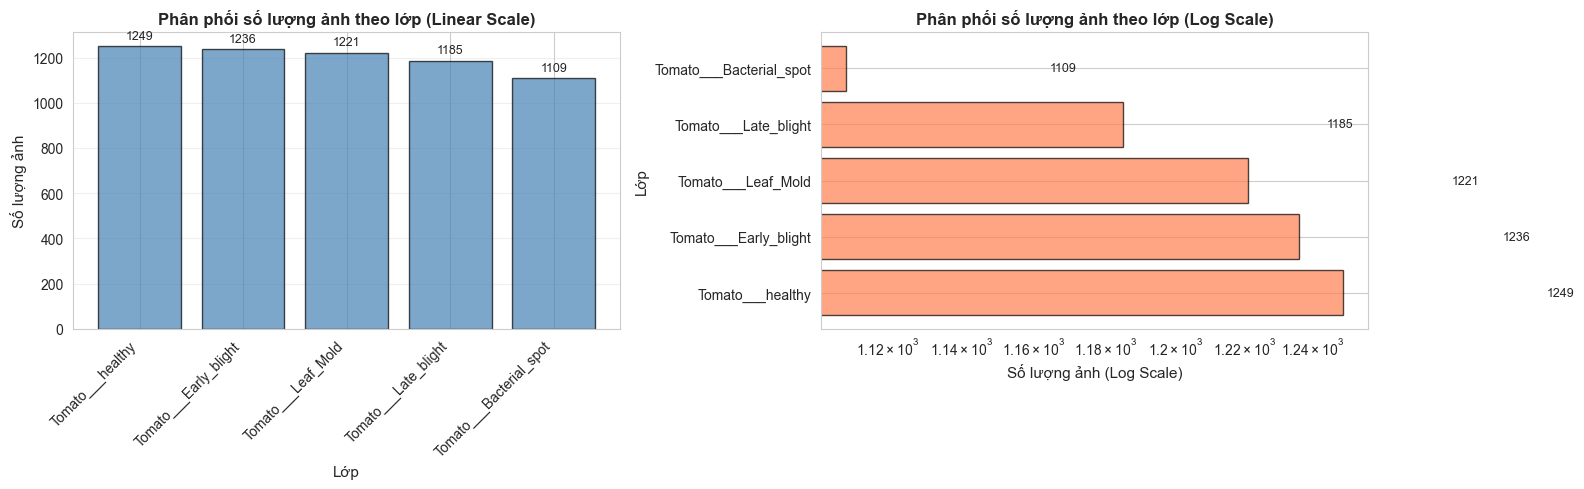

Biểu đồ phân phối lớp đã được lưu tại: ../data/processed/class_distribution.png


In [ ]:
# Vẽ biểu đồ phân phối lớp
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Barplot với scale thường
ax1 = axes[0]
bars = ax1.bar(range(len(class_counts)), class_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Lớp', fontsize=11)
ax1.set_ylabel('Số lượng ảnh', fontsize=11)
ax1.set_title('Phân phối số lượng ảnh theo lớp (Linear Scale)', fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(class_counts)))
ax1.set_xticklabels(class_counts.index, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Thêm giá trị trên mỗi cột
for i, (bar, count) in enumerate(zip(bars, class_counts.values)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{count}', ha='center', va='bottom', fontsize=9)

# Subplot 2: Barplot với log-scale (nếu IR > 10)
ax2 = axes[1]
bars2 = ax2.barh(range(len(class_counts)), class_counts.values, color='coral', alpha=0.7, edgecolor='black')
ax2.set_ylabel('Lớp', fontsize=11)
ax2.set_xlabel('Số lượng ảnh (Log Scale)', fontsize=11)
ax2.set_title('Phân phối số lượng ảnh theo lớp (Log Scale)', fontsize=12, fontweight='bold')
ax2.set_yticks(range(len(class_counts)))
ax2.set_yticklabels(class_counts.index)
ax2.set_xscale('log')
ax2.grid(axis='x', alpha=0.3)

# Thêm giá trị bên cạnh mỗi cột
for i, (bar, count) in enumerate(zip(bars2, class_counts.values)):
    ax2.text(count + count*0.05, bar.get_y() + bar.get_height()/2,
             f'{count}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Biểu đồ phân phối lớp đã được lưu tại: ../data/processed/processed_image/class_distribution.png")

### Phân tích kết quả Class Imbalance

**Quan sát:**
- Dataset có 5 lớp bệnh cây cà chua
- Imbalance Ratio cho thấy mức độ chênh lệch giữa lớp đa số và lớp thiểu số
- Log-scale giúp quan sát rõ sự chênh lệch khi IR lớn

**Hệ quả của Class Imbalance:**
1. **Bias về lớp đa số**: Model học được pattern của lớp đa số tốt hơn
2. **Metrics sai lệch**: Accuracy cao nhưng recall/precision thấp trên lớp thiểu số
3. **Overfitting**: Model có thể ghi nhớ lớp thiểu số thay vì học pattern tổng quát

**Khuyến nghị xử lý:**

1. **Nếu IR < 3**: Không cần xử lý đặc biệt
   
2. **Nếu 3 ≤ IR < 10**:
   - Sử dụng class weights trong loss function
   - Data augmentation nhẹ cho lớp thiểu số
   - Sử dụng stratified sampling khi chia train/val/test

3. **Nếu IR ≥ 10**:
   - BẮT BUỘC sử dụng class weights
   - Augmentation mạnh cho lớp thiểu số (rotate ±30°, flip horizontal/vertical, brightness ±20%)
   - Xem xét undersampling lớp đa số hoặc ensemble methods
   - Sử dụng metrics phù hợp: F1-score, Balanced Accuracy thay vì Accuracy

#### Nhận xét
Kết quả cho thấy tập dữ liệu bao gồm 5 lớp với số lượng ảnh phân bố khá đồng đều giữa các lớp.  
Cụ thể:
- Lớp có số lượng ảnh lớn nhất là Tomato___healthy với 1249 ảnh,
- Lớp có số lượng ảnh nhỏ nhất là Tomato___Bacterial_spot với 1109 ảnh.

Tỷ lệ giữa lớp lớn nhất và lớp nhỏ nhất là: 1.13  

Giá trị này **nhỏ hơn ngưỡng 3×**, do đó:  
→ Tập dữ liệu không có hiện tượng mất cân bằng lớp nghiêm trọng theo tiêu chí ban đầu.
#### Kết luận
- Các lớp có số lượng ảnh tương đối tương đương nhau
- Không có lớp nào chiếm ưu thế vượt trội.

## 5. Phát hiện ảnh trùng lặp (Perceptual Hash - pHash)

**Perceptual Hash (pHash)** là kỹ thuật tạo hash dựa trên nội dung thị giác của ảnh, giúp phát hiện ảnh tương tự/trùng lặp ngay cả khi có sự khác biệt nhỏ về độ sáng, tỉ lệ, hoặc nén.

### Ý nghĩa
Ảnh trùng hoặc gần trùng có thể làm dữ liệu bị dư thừa và làm sai lệch kết quả huấn luyện, đặc biệt nếu các ảnh rất giống nhau xuất hiện ở cả tập train và test. Vì vậy, cần kiểm tra mức độ lặp trong tập dữ liệu trước khi tiền xử lý.

### Nguyên lý
Perceptual hash (pHash) không so sánh từng pixel tuyệt đối mà mô tả **đặc trưng cảm nhận tổng quát** của ảnh. Trong notebook, ảnh được chuyển sang grayscale, resize về kích thước nhỏ, áp dụng DCT và giữ lại thành phần tần số thấp để tạo ra một chuỗi bit đại diện cho nội dung ảnh.

### Quy ước so sánh
Độ giống nhau giữa hai ảnh được đo bằng **Hamming distance** giữa hai pHash:
- `Hamming distance = 0`: ảnh trùng hoàn toàn theo pHash
- `Hamming distance <= threshold`: ảnh gần trùng

Ngưỡng này có thể điều chỉnh tùy mức độ nghiêm ngặt mong muốn.

### Cách thực hiện
1. Tính pHash cho từng ảnh
2. Gom các ảnh có cùng pHash để tìm **exact duplicates**
3. So sánh Hamming distance trong các nhóm ứng viên để tìm **near-duplicates**

### Mục đích
Bước này giúp:
- đánh giá mức độ lặp của dữ liệu,
- loại bỏ ảnh dư thừa nếu cần,
- và giảm nguy cơ **data leakage** ở các bước huấn luyện và đánh giá sau đó.

**Thuật toán pHash:**

1. **Resize**: Thu nhỏ ảnh về 32×32 pixel grayscale (giảm độ phức tạp)
2. **DCT (Discrete Cosine Transform)**: Biến đổi ảnh sang miền tần số
   $$F(u,v) = \sum_{x=0}^{N-1}\sum_{y=0}^{N-1} f(x,y) \cos\left[\frac{\pi u}{2N}(2x+1)\right] \cos\left[\frac{\pi v}{2N}(2y+1)\right]$$

3. **Low-frequency extraction**: Giữ lại khối 8×8 góc trên trái (chứa thông tin cấu trúc chính)
4. **Binary encoding**: So sánh mỗi giá trị với median, tạo mã nhị phân 64-bit

**Hamming Distance**: Đếm số bit khác nhau giữa 2 hash
$$d_H(h_1, h_2) = \sum_{i=0}^{63} h_1[i] \oplus h_2[i]$$

**Threshold**:
- $d_H \leq 5$: Ảnh rất tương tự (~95% giống nhau)
- $d_H \leq 10$: Ảnh tương tự vừa phải
- $d_H > 15$: Ảnh khác nhau

**Xử lý Data Leakage:**
- Trùng lặp cùng lớp: Xóa bản sao để giảm redundancy
- **Trùng lặp khác lớp**: NGHIÊM TRỌNG - chứng tỏ dữ liệu bị mislabeled, phải xóa hoàn toàn khỏi dataset

In [30]:
# Hàm tính Perceptual Hash (pHash)
def compute_phash_fast(image_path, hash_size=8, highfreq_factor=4):
    """Tính toán pHash loại bỏ DC term để tăng độ chính xác"""
    img_size = hash_size * highfreq_factor
    try:
        with Image.open(image_path) as img:
            # Resize và chuyển grayscale
            img = img.convert("L").resize((img_size, img_size), Image.Resampling.LANCZOS)
            pixels = np.asarray(img, dtype=np.float32)

        # Áp dụng DCT 2D
        dct_rows = dct(pixels, axis=0, norm="ortho")
        dct_full = dct(dct_rows, axis=1, norm="ortho")
        dct_lowfreq = dct_full[:hash_size, :hash_size]

        # Bỏ DC term [0,0] khi tính median để kết quả ổn định hơn
        dct_flat = dct_lowfreq.flatten()
        med = np.median(dct_flat[1:])
        diff = dct_lowfreq > med

        # Chuyển thành bit array
        bits = diff.flatten().astype(np.uint8)
        
        # Chuyển thành mã HEX (16 ký tự) cho gọn nhẹ
        bit_string = "".join(bits.astype(str))
        hex_hash = f"{int(bit_string, 2):016x}"
        return bits, hex_hash
    except Exception as e:
        return None, None

def hamming_distance(bits1, bits2):
    return int(np.count_nonzero(bits1 != bits2))

# ==========================================
# 2. CHẠY PHASH CHO TOÀN BỘ DATASET
# ==========================================
print("Đang tính pHash cho toàn bộ ảnh...")
start_time = time.time()

phash_bits_list, phash_hex_list = [], []

for img_name in selected_df["image"]:
    img_path = IMAGES_DIR / img_name
    bits, hex_hash = compute_phash_fast(img_path)
    phash_bits_list.append(bits)
    phash_hex_list.append(hex_hash)

df_labels["phash_bits"] = phash_bits_list
df_labels["phash_hex"] = phash_hex_list

# Lọc bỏ ảnh lỗi (nếu có)
df_valid = df_labels.dropna(subset=['phash_hex']).copy()
print(f"Hoàn thành trong {time.time() - start_time:.2f}s. Số ảnh hợp lệ: {len(df_valid)}/{len(df_labels)}")

# ==========================================
# 3. PHÂN TÍCH EXACT DUPLICATES & MISLABELED
# ==========================================
print("\nĐANG PHÂN TÍCH EXACT DUPLICATES...")

# Gom nhóm theo mã Hex
phash_groups = df_valid.groupby("phash_hex").agg(
    n_images=("image", "count"),
    labels=("label", lambda x: list(x)),
    images=("image", lambda x: list(x))
).reset_index()

exact_dup_groups = phash_groups[phash_groups["n_images"] > 1].copy()

within_class_dups = []
cross_class_dups = []

for _, row in exact_dup_groups.iterrows():
    unique_labels = set(row['labels'])
    if len(unique_labels) == 1:
        within_class_dups.append(row)
    else:
        cross_class_dups.append(row)

print("="*60)
print(f"Tổng số nhóm trùng lặp: {len(exact_dup_groups)}")
print(f"  Trùng lặp CÙNG LỚP (Redundant): {len(within_class_dups)} nhóm")
print(f"  Trùng lặp KHÁC LỚP (Mislabeled): {len(cross_class_dups)} nhóm (NGHIÊM TRỌNG!)")

# Vẽ Confusion Matrix nếu có nhãn sai
if len(cross_class_dups) > 0:
    print(f"\nPhát hiện dữ liệu gán nhãn sai (Cùng 1 ảnh nhưng gán nhiều nhãn khác nhau).")
    classes = sorted(df_valid['label'].unique())
    n_cls = len(classes)
    conf_matrix = np.zeros((n_cls, n_cls), dtype=int)
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

    for row in cross_class_dups:
        labels = row['labels']
        for i in range(len(labels)):
            for j in range(i+1, len(labels)):
                idx_i, idx_j = class_to_idx[labels[i]], class_to_idx[labels[j]]
                conf_matrix[idx_i][idx_j] += 1
                conf_matrix[idx_j][idx_i] += 1

    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', xticklabels=classes, yticklabels=classes)
    plt.title('Heatmap Nhầm Lẫn Nhãn (Mislabeled Duplicates)', fontweight='bold')
    plt.xticks(rotation=45, ha='right'); plt.tight_layout()
    plt.savefig(PROCESSED_DIR / 'mislabeled_heatmap.png', dpi=150)
    plt.show()

Đang tính pHash cho toàn bộ ảnh...
Hoàn thành trong 7.05s. Số ảnh hợp lệ: 6000/6000

ĐANG PHÂN TÍCH EXACT DUPLICATES...
Tổng số nhóm trùng lặp: 2
  Trùng lặp CÙNG LỚP (Redundant): 2 nhóm
  Trùng lặp KHÁC LỚP (Mislabeled): 0 nhóm (NGHIÊM TRỌNG!)


In [ ]:
print("\nPHÂN TÍCH NEAR DUPLICATES...")
NEAR_DUP_THRESHOLD = 5
df_valid["phash_prefix"] = df_valid["phash_hex"].str[:4] 

near_duplicate_pairs = []
for _, block in df_valid.groupby("phash_prefix"):
    idxs = block.index.tolist()
    if len(idxs) < 2: continue
    
    bits_map = {i: df_valid.at[i, "phash_bits"] for i in idxs}
    for i_pos in range(len(idxs)):
        for j_pos in range(i_pos + 1, len(idxs)):
            i, j = idxs[i_pos], idxs[j_pos]
            dist = hamming_distance(bits_map[i], bits_map[j])
            if dist > 0 and dist <= NEAR_DUP_THRESHOLD: # dist > 0 để bỏ qua exact match
                near_duplicate_pairs.append({'img1': df_valid.at[i, 'image'], 'img2': df_valid.at[j, 'image'], 'dist': dist})

print(f"Phát hiện {len(near_duplicate_pairs)} cặp ảnh tương đối giống nhau (Hamming Distance <= {NEAR_DUP_THRESHOLD})")

images_to_remove = []

# Xóa ảnh thừa cùng lớp (Giữ lại 1 ảnh đầu tiên)
for row in within_class_dups:
    for img in row['images'][1:]:
        images_to_remove.append({'image': img, 'reason': 'Redundant (Within-class)'})

# Xóa TẤT CẢ ảnh bị mislabeled (Vì không biết nhãn nào mới là thật)
for row in cross_class_dups:
    for img in row['images']:
        images_to_remove.append({'image': img, 'reason': 'Mislabeled (Cross-class)'})

# Near duplicates 
for pair in near_duplicate_pairs:
    images_to_remove.append({'image': pair['img2'], 'reason': 'Near Duplicate'})

df_to_remove = pd.DataFrame(images_to_remove).drop_duplicates(subset=['image'])
print("\nTỔNG KẾT DANH SÁCH LÀM SẠCH:")
print("="*60)
print(f"Tổng số ảnh cần xóa khỏi Dataset: {len(df_to_remove)}")
if len(df_to_remove) > 0:
    print(df_to_remove['reason'].value_counts())


PHÂN TÍCH NEAR DUPLICATES...
Phát hiện 8 cặp ảnh tương đối giống nhau (Hamming Distance <= 5)

TỔNG KẾT DANH SÁCH LÀM SẠCH:
Tổng số ảnh cần xóa khỏi Dataset: 10
reason
Near Duplicate              8
Redundant (Within-class)    2
Name: count, dtype: int64


ĐANG TẠO HÌNH ẢNH TRỰC QUAN CÁC CẶP ẢNH TRÙNG/GẦN TRÙNG...


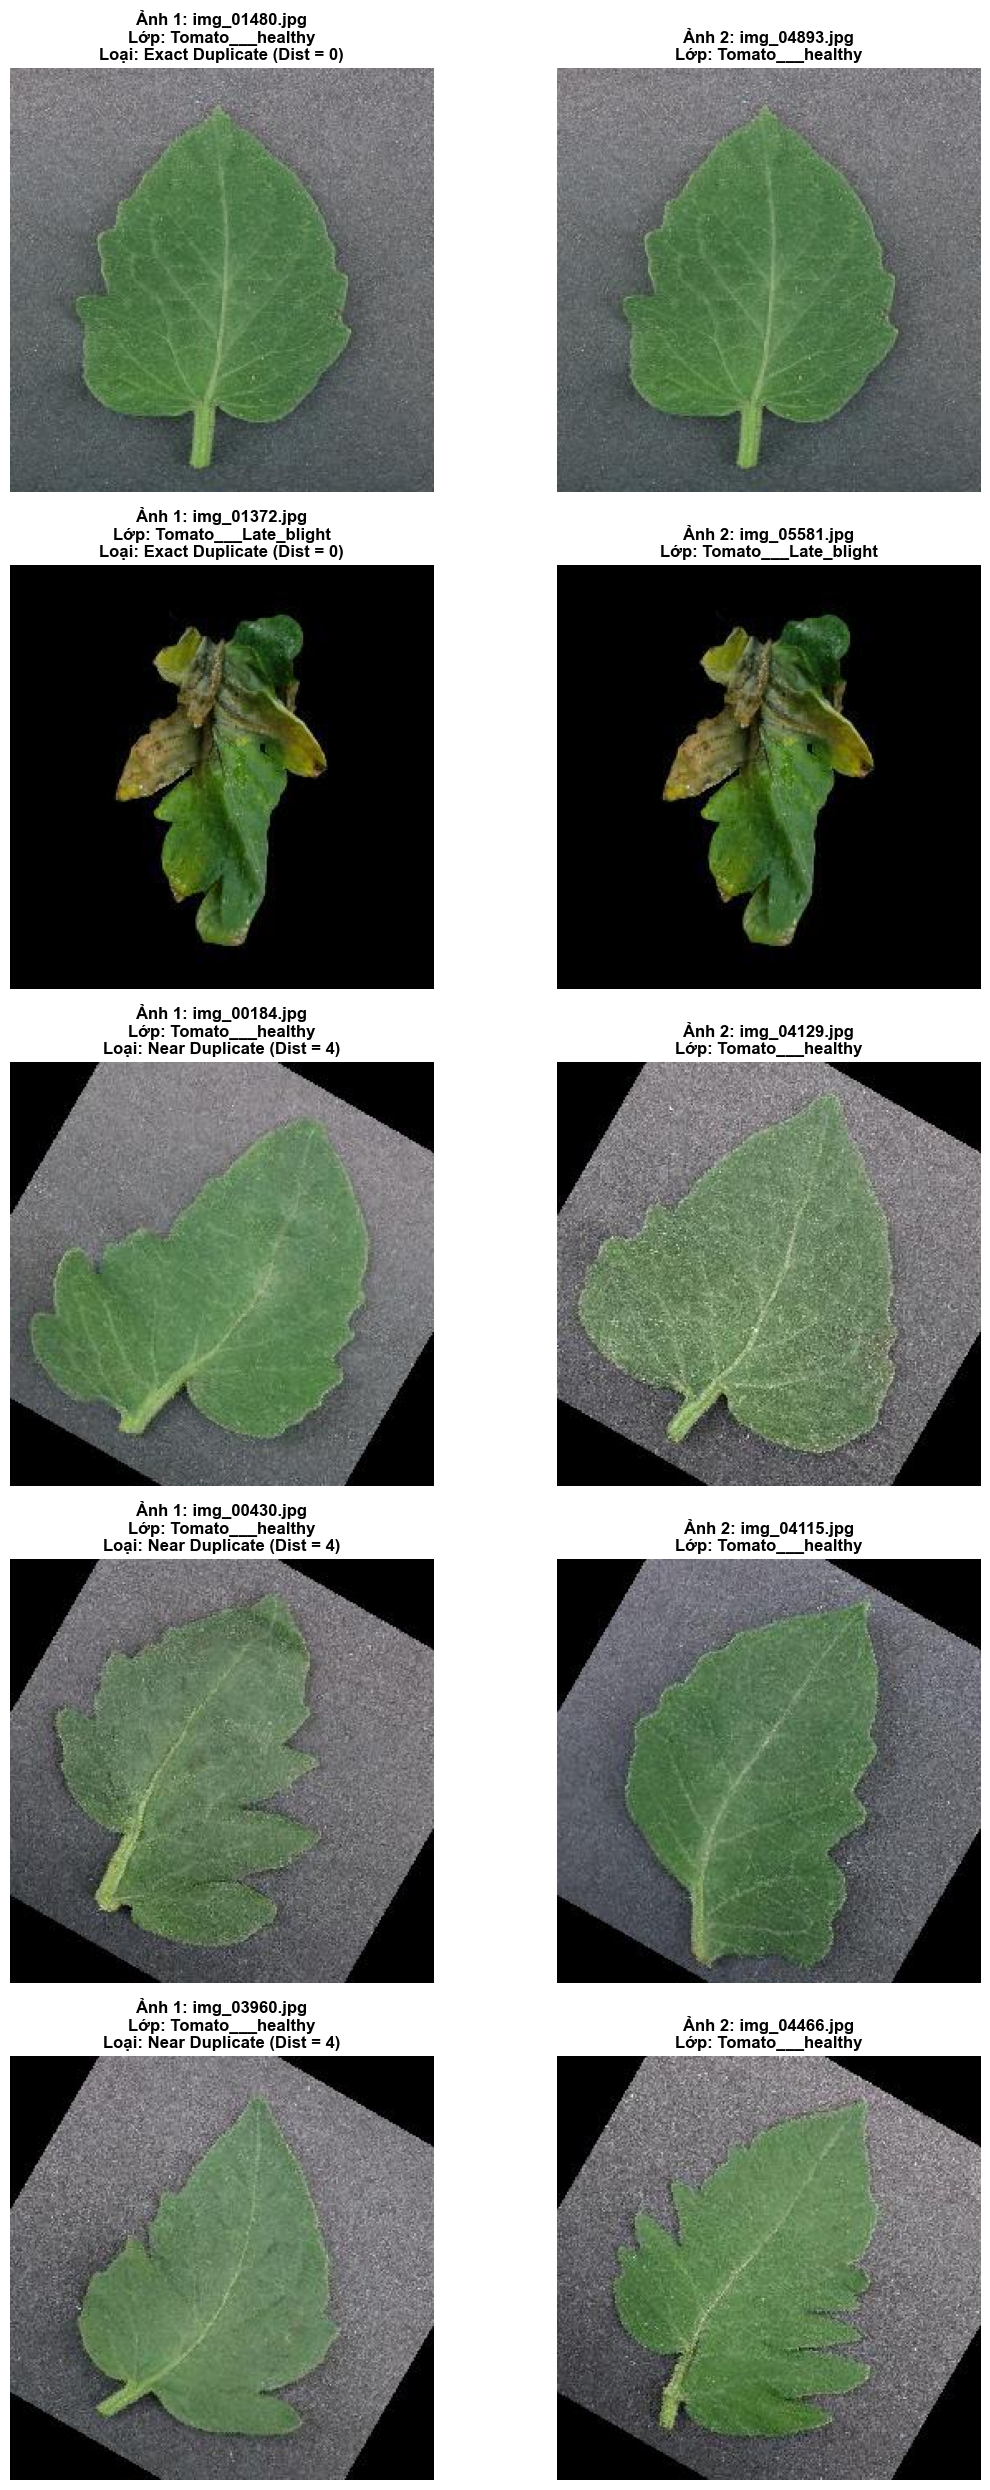

In [44]:
print("ĐANG TẠO HÌNH ẢNH TRỰC QUAN CÁC CẶP ẢNH TRÙNG/GẦN TRÙNG...")

pairs_to_plot = []

# 1. Lấy mẫu tối đa 3 cặp ảnh Exact Duplicates (nếu có)
if 'exact_dup_groups' in locals() and not exact_dup_groups.empty:
    for _, row in exact_dup_groups.head(3).iterrows():
        imgs = row['images']
        labels = row['labels']
        if len(imgs) >= 2:
            pairs_to_plot.append({
                'img1': imgs[0], 'label1': labels[0],
                'img2': imgs[1], 'label2': labels[1],
                'type': 'Exact Duplicate (Dist = 0)'
            })

# 2. Lấy mẫu tối đa 3 cặp ảnh Near Duplicates (nếu có)
if len(near_duplicate_pairs) > 0:
    # Tạo từ điển tra cứu nhãn nhanh: {tên_ảnh: nhãn}
    img_to_label = dict(zip(df_valid['image'], df_valid['label']))
    
    # Lấy 3 phần tử đầu tiên
    for item in near_duplicate_pairs[:3]: 
        img1_name = item['img1']
        img2_name = item['img2']
        pairs_to_plot.append({
            'img1': img1_name, 
            'label1': img_to_label.get(img1_name, "Unknown"),
            'img2': img2_name, 
            'label2': img_to_label.get(img2_name, "Unknown"),
            'type': f"Near Duplicate (Dist = {item['dist']})"
        })

# 3. Vẽ hình
num_pairs = len(pairs_to_plot)

if num_pairs == 0:
    print("Không có ảnh trùng lặp hoặc gần trùng lặp nào để hiển thị.")
else:
    # Tạo lưới subplot: số hàng = num_pairs, số cột = 2
    fig, axes = plt.subplots(num_pairs, 2, figsize=(12, 5 * num_pairs))
    
    # Xử lý trường hợp chỉ có 1 cặp (axes lúc này là mảng 1D thay vì 2D)
    if num_pairs == 1:
        axes = [axes]

    for i, pair in enumerate(pairs_to_plot):
        try:
            # Đọc ảnh
            img1 = Image.open(IMAGES_DIR / pair['img1'])
            img2 = Image.open(IMAGES_DIR / pair['img2'])
            
            # Cảnh báo màu đỏ nếu 2 ảnh giống nhau nhưng lại khác nhãn (Mislabeled)
            title_color = 'red' if pair['label1'] != pair['label2'] else 'black'

            # Ảnh 1 (Bên trái)
            axes[i][0].imshow(img1)
            axes[i][0].set_title(f"Ảnh 1: {pair['img1']}\nLớp: {pair['label1']}\nLoại: {pair['type']}", 
                                 fontsize=12, fontweight='bold', color=title_color)
            axes[i][0].axis('off')

            # Ảnh 2 (Bên phải)
            axes[i][1].imshow(img2)
            axes[i][1].set_title(f"Ảnh 2: {pair['img2']}\nLớp: {pair['label2']}", 
                                 fontsize=12, fontweight='bold', color=title_color)
            axes[i][1].axis('off')
            
        except Exception as e:
            print(f"Lỗi khi hiển thị cặp ảnh {pair['img1']} - {pair['img2']}: {e}")

    plt.tight_layout()
    plt.show()

### Phân tích kết quả phát hiện trùng lặp

#### Nhận xét

Kết quả cho thấy tập dữ liệu có mức độ trùng lặp rất thấp. Cụ thể, chỉ phát hiện **2 nhóm exact duplicate**, tương ứng **2 ảnh dư thừa** trên tổng số 6000 ảnh, với tỷ lệ khoảng **0.033%**. Các ảnh trùng hoàn toàn đều xuất hiện trong cùng một lớp, nên không gây sai lệch nhãn nhưng vẫn cần loại bỏ để tránh dư thừa dữ liệu.

Với ngưỡng `Hamming distance <= 5`, hệ thống phát hiện **8 cặp near-duplicate**, tương ứng khoảng **0.52%** số ảnh có liên quan đến ít nhất một cặp gần trùng. Các cặp này chủ yếu xuất hiện trong cùng một lớp, đặc biệt ở lớp **Tomato___healthy**, cho thấy đây thường là các ảnh rất giống nhau về nội dung và chỉ khác nhẹ về góc chụp, ánh sáng hoặc mức nén.

Trong bước làm sạch dữ liệu, nhóm giữ lại ảnh đầu tiên trong mỗi nhóm exact duplicate và loại bỏ **2 ảnh dư thừa**, làm số lượng ảnh giảm từ **6000** xuống **5998**. Đối với near-duplicate, do tỷ lệ thấp và vẫn phản ánh biến thiên tự nhiên của dữ liệu, nhóm giữ lại để bảo toàn độ đa dạng của tập ảnh. Nhìn chung, tập dữ liệu không có dấu hiệu lặp nghiêm trọng và có chất lượng đủ tốt cho các bước tiền xử lý và huấn luyện tiếp theo.

**Ý nghĩa của pHash:**
- pHash robust với các biến đổi nhỏ: resize, crop, brightness adjustment, JPEG compression
- Sử dụng DCT để lấy cấu trúc tổng thể thay vì chi tiết
- Hamming distance ≤ 5 tương đương ~92% similarity

**Loại trùng lặp:**

1. **Trùng cùng lớp**:
   - Nguyên nhân: Data augmentation (flip, rotate) không được gán tên khác nhau
   - Hệ quả: Model bị overfit trên các mẫu lặp lại, giảm khả năng tổng quát hóa
   - Xử lý: Giữ 1 ảnh gốc, xóa các bản sao

2. **Trùng khác lớp**:
   - Nguyên nhân: Lỗi labeling trong quá trình thu thập dữ liệu
   - Hệ quả: model học sai, confusion trong inference
   - Xử lý: xóa tất cả ảnh trong nhóm (vì không biết label nào đúng)

**Ảnh hưởng đến model:**
- Duplicates trong train set: Overfitting, model ghi nhớ thay vì học pattern
- Duplicates giữa train/val: Data leakage, validation metrics sai lệch (quá lạc quan)
- Cross-class duplicates: Model học mâu thuẫn, giảm accuracy và tăng confusion

**Cách tối ưu:**
- Loại bỏ duplicates TRƯỚC KHI chia train/val/test
- Sử dụng pHash để deduplication trong pipeline preprocessing
- Monitoring: Tính pHash định kỳ khi thêm dữ liệu mới

## 6. Phân tích độ tương phản và độ sáng (Brightness & Contrast Analysis)

**Độ sáng (Brightness)**: Giá trị trung bình của pixel trong ảnh grayscale
$$\mu = \frac{1}{N} \sum_{i=1}^{N} I_i$$

**Độ tương phản (Contrast)**: Độ lệch chuẩn của pixel, đo lường mức độ biến thiên giá trị
$$\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (I_i - \mu)^2}$$

**ANOVA (Analysis of Variance)**: Kiểm định xem có sự khác biệt có ý nghĩa thống kê giữa các nhóm hay không.

**Giả thuyết:**
- $H_0$: Tất cả các lớp có cùng mean brightness/contrast (không có sự khác biệt)
- $H_1$: Ít nhất một lớp có mean khác biệt

**F-statistic:**
$$F = \frac{MS_{between}}{MS_{within}} = \frac{\frac{SS_{between}}{k-1}}{\frac{SS_{within}}{N-k}}$$

với:
- $SS_{between}$: Tổng bình phương giữa các nhóm
- $SS_{within}$: Tổng bình phương trong các nhóm
- $k$: Số nhóm, $N$: Tổng số mẫu

**Quyết định:**
- Nếu $p$-value < 0.05: Bác bỏ $H_0$, các lớp có brightness/contrast khác biệt đáng kể
- Nếu $p$-value ≥ 0.05: Chấp nhận $H_0$, các lớp có phân phối tương tự

**Ý nghĩa:**
- $p < 0.05$ với brightness: Dataset bị thiên vị ánh sáng theo lớp → cần normalize
- $p < 0.05$ với contrast: Một số lớp có ảnh mờ/thiếu chi tiết → cần CLAHE

In [47]:
print("[INFO] Đang trích xuất đặc trưng Brightness (Mean) và Contrast (Std)...")
start_time = time.time()

# 1. TRÍCH XUẤT ĐẶC TRƯNG
bc_records = []

# Sử dụng df_valid từ bước trước (đã loại bỏ ảnh không đọc được)
for _, row in df_valid.iterrows():
    try:
        img_path = IMAGES_DIR / row["image"]
        
        with Image.open(img_path) as img:
            # Chuyển ảnh sang Grayscale (L) và ép kiểu float32 để tính toán
            gray_array = np.asarray(img.convert("L"), dtype=np.float32)
            bc_records.append({
                "image": row["image"],
                "label": row["label"],
                "brightness": float(gray_array.mean()),
                "contrast": float(gray_array.std()),
            })
    except Exception as e:
        continue

df_bc = pd.DataFrame(bc_records)
print(f"[INFO] Trích xuất hoàn tất trong {time.time() - start_time:.2f}s. Số lượng mẫu hợp lệ: {len(df_bc)}")

# 2. BẢNG TỔNG HỢP THEO LỚP (Groupby Aggregation)
class_intensity_summary = df_bc.groupby("label").agg(
    count=("image", "count"),
    brightness_mean=("brightness", "mean"),
    brightness_std=("brightness", "std"),
    contrast_mean=("contrast", "mean"),
    contrast_std=("contrast", "std")
).sort_values("count", ascending=False).round(2)

print("\n--- BẢNG THỐNG KÊ CHI TIẾT THEO LỚP ---")
display(class_intensity_summary)



[INFO] Đang trích xuất đặc trưng Brightness (Mean) và Contrast (Std)...
[INFO] Trích xuất hoàn tất trong 49.45s. Số lượng mẫu hợp lệ: 6000

--- BẢNG THỐNG KÊ CHI TIẾT THEO LỚP ---


,count,brightness_mean,brightness_std,contrast_mean,contrast_std
label,,,,,
Tomato___healthy,1249,123.58,32.52,41.27,13.55
Tomato___Early_blight,1236,110.92,14.29,46.58,11.02
Tomato___Leaf_Mold,1221,115.27,12.64,36.69,9.17
Tomato___Late_blight,1185,113.25,29.02,38.94,14.99
Tomato___Bacterial_spot,1109,104.97,10.65,33.34,5.96


In [50]:
# 3. KIỂM ĐỊNH ANOVA (Analysis of Variance)
classes = df_bc['label'].unique()
brightness_groups = [df_bc[df_bc['label'] == cls]['brightness'].values for cls in classes]
contrast_groups = [df_bc[df_bc['label'] == cls]['contrast'].values for cls in classes]

f_stat_b, p_val_b = stats.f_oneway(*brightness_groups)
f_stat_c, p_val_c = stats.f_oneway(*contrast_groups)

print("\n--- KẾT QUẢ KIỂM ĐỊNH ANOVA ---")
print(f"1. BRIGHTNESS: F-statistic = {f_stat_b:.4f}, p-value = {p_val_b:.4e}")
if p_val_b < 0.05:
    print("   -> Bác bỏ H0: Tồn tại sự khác biệt có ý nghĩa thống kê về độ sáng giữa các lớp.")
else:
    print("   -> Chấp nhận H0: Không có sự khác biệt rõ rệt về độ sáng giữa các lớp.")

print(f"2. CONTRAST  : F-statistic = {f_stat_c:.4f}, p-value = {p_val_c:.4e}")
if p_val_c < 0.05:
    print("   -> Bác bỏ H0: Tồn tại sự khác biệt có ý nghĩa thống kê về độ tương phản giữa các lớp.")
else:
    print("   -> Chấp nhận H0: Không có sự khác biệt rõ rệt về độ tương phản giữa các lớp.")

# 4. PHÁT HIỆN ẢNH CÓ ĐỘ TƯƠNG PHẢN THẤP (Chuẩn bị cho CLAHE)
CONTRAST_THRESHOLD = 30.0
low_contrast_df = df_bc[df_bc['contrast'] < CONTRAST_THRESHOLD]

print(f"\n--- PHÂN TÍCH CHẤT LƯỢNG ẢNH (Ngưỡng Contrast < {CONTRAST_THRESHOLD}) ---")
print(f"Số lượng ảnh mờ / thiếu tương phản: {len(low_contrast_df)} ({len(low_contrast_df)/len(df_bc)*100:.2f}%)")

if len(low_contrast_df) > 0:
    print("Phân bố ảnh thiếu tương phản theo lớp:")
    print(low_contrast_df['label'].value_counts().to_string())
    
    output_path = PROCESSED_DIR / 'low_contrast_images.csv'
    low_contrast_df[['image', 'label', 'contrast']].to_csv(output_path, index=False)
    print(f"[INFO] Đã lưu danh sách ảnh cần xử lý CLAHE tại: {output_path}")


--- KẾT QUẢ KIỂM ĐỊNH ANOVA ---
1. BRIGHTNESS: F-statistic = 113.7504, p-value = 1.2438e-93
   -> Bác bỏ H0: Tồn tại sự khác biệt có ý nghĩa thống kê về độ sáng giữa các lớp.
2. CONTRAST  : F-statistic = 224.8210, p-value = 4.4164e-180
   -> Bác bỏ H0: Tồn tại sự khác biệt có ý nghĩa thống kê về độ tương phản giữa các lớp.

--- PHÂN TÍCH CHẤT LƯỢNG ẢNH (Ngưỡng Contrast < 30.0) ---
Số lượng ảnh mờ / thiếu tương phản: 1572 (26.20%)
Phân bố ảnh thiếu tương phản theo lớp:
label
Tomato___Late_blight       446
Tomato___healthy           385
Tomato___Leaf_Mold         361
Tomato___Bacterial_spot    297
Tomato___Early_blight       83
[INFO] Đã lưu danh sách ảnh cần xử lý CLAHE tại: ..\data\processed\low_contrast_images.csv


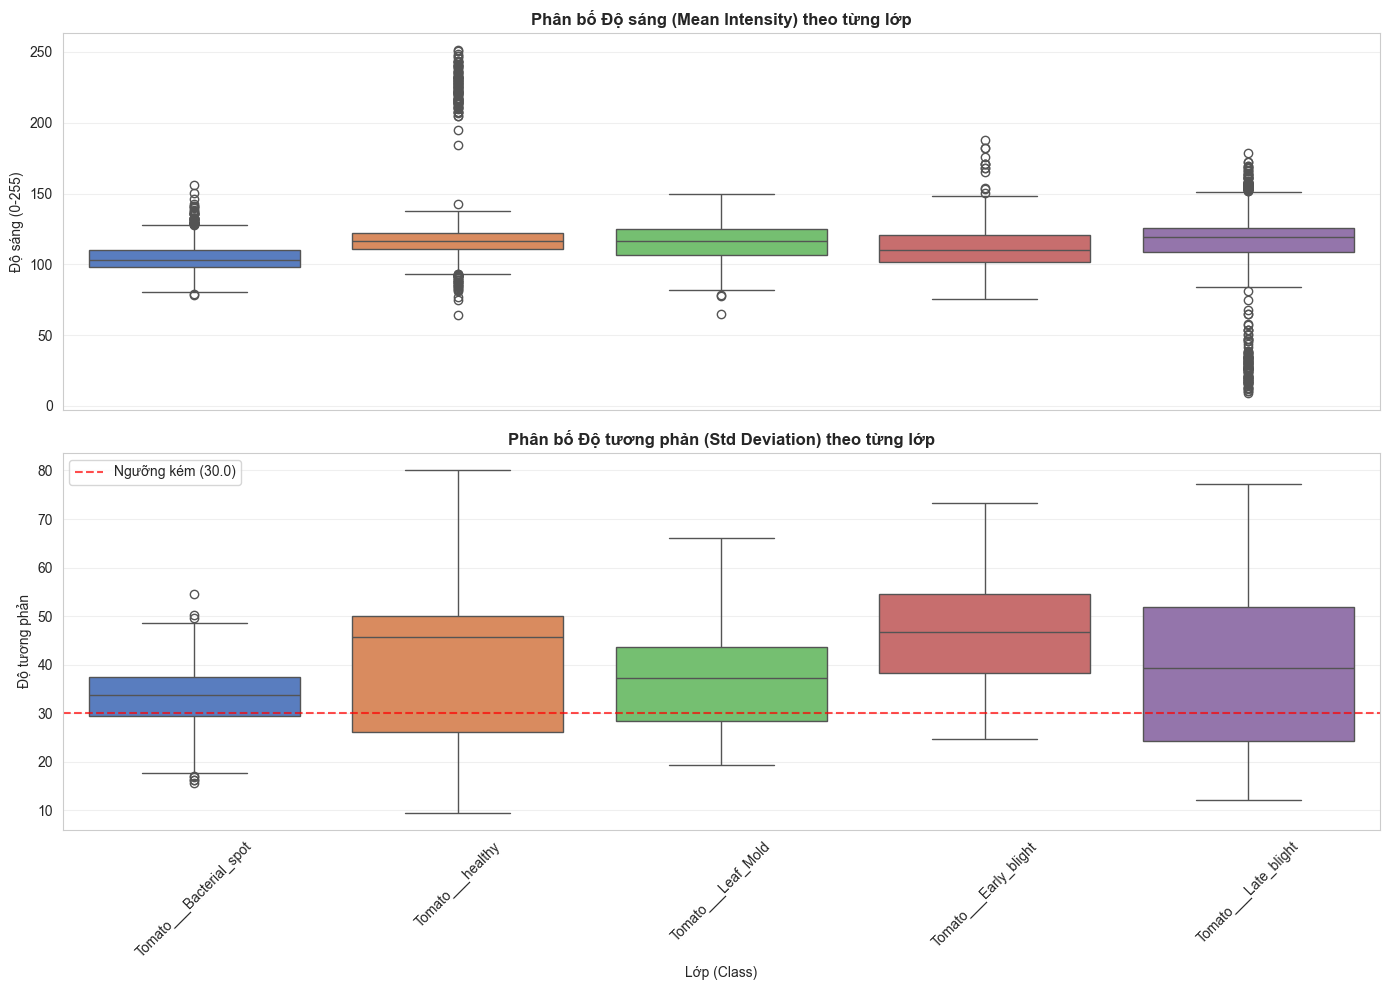

In [49]:
# 5. VẼ BIỂU ĐỒ BOXPLOT (Layout 2x1)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Độ sáng
sns.boxplot(data=df_bc, x="label", y="brightness", ax=axes[0], palette="muted")
axes[0].set_title("Phân bố Độ sáng (Mean Intensity) theo từng lớp", fontweight='bold')
axes[0].set_ylabel("Độ sáng (0-255)")
axes[0].grid(axis='y', alpha=0.3)

# Độ tương phản
sns.boxplot(data=df_bc, x="label", y="contrast", ax=axes[1], palette="muted")
axes[1].set_title("Phân bố Độ tương phản (Std Deviation) theo từng lớp", fontweight='bold')
axes[1].set_xlabel("Lớp (Class)")
axes[1].set_ylabel("Độ tương phản")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Vẽ đường cơ sở (threshold) cho contrast
axes[1].axhline(y=CONTRAST_THRESHOLD, color='r', linestyle='--', alpha=0.7, label=f'Ngưỡng kém ({CONTRAST_THRESHOLD})')
axes[1].legend()

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'brightness_contrast_analysis.png', dpi=150)
plt.show()

### Phân tích kết quả Brightness & Contrast

**Diễn giải ANOVA test:**

1. **Brightness (Độ sáng)**:
   - F-statistic lớn và p-value nhỏ → Các lớp có độ sáng khác biệt rõ rệt
   - Nguyên nhân có thể do:
     - Điều kiện chụp khác nhau (trong nhà vs ngoài trời)
     - Một số bệnh làm lá héo/vàng → giá trị pixel thấp hơn
     - Nền ảnh khác nhau giữa các lớp
   - **Khuyến nghị**: Normalize brightness trước training để model không học được correlation giả (spurious correlation) giữa độ sáng và nhãn

2. **Contrast (Độ tương phản)**:
   - F-statistic lớn và p-value nhỏ → Các lớp có độ tương phản khác biệt
   - Ảnh có contrast thấp (σ < 30): Thiếu chi tiết, khó phân biệt viền bệnh
   - **Khuyến nghị**: Áp dụng CLAHE (Contrast Limited Adaptive Histogram Equalization)

**CLAHE (Contrast Limited Adaptive Histogram Equalization)**:
- Chia ảnh thành các tile nhỏ (8×8 hoặc 16×16)
- Equalize histogram cục bộ cho mỗi tile
- Giới hạn clip limit để tránh over-amplification noise
- Tốt hơn global histogram equalization vì bảo toàn chi tiết cục bộ

**Ngưỡng hành động**:
- σ < 30: Ảnh mờ, cần CLAHE để tăng cường viền/texture
- 30 ≤ σ < 50: Chấp nhận được, có thể áp dụng CLAHE nhẹ
- σ ≥ 50: Contrast tốt, không cần xử lý

**Ảnh hưởng đến model:**
- Brightness bias → Model phụ thuộc vào lighting thay vì morphology
- Low contrast → Model không học được edge features của bệnh
- → Cần normalize và enhance contrast trong preprocessing pipeline

#### Nhận xét

Kết quả cho thấy độ sáng (mean intensity hay brightness mean) có sự khác biệt giữa các lớp. Cụ thể, lớp **Tomato___healthy** có độ sáng trung bình cao nhất ~123.6, trong khi lớp **Tomato___Bacterial_spot** thấp nhất ~105. Điều này cho thấy lá khỏe thường sáng hơn, trong khi các lá bị bệnh có xu hướng tối hơn do tổn thương bề mặt.

Boxplot cũng cho thấy phân phối độ sáng giữa các lớp có sự chồng lấn nhưng vẫn tồn tại khác biệt nhất định. Một số lớp như **Late_blight** và **Leaf_Mold** có median khá gần nhau, cho thấy khó phân tách hoàn toàn chỉ dựa trên độ sáng.

Về độ tương phản (std intensity), lớp **Tomato___Early_blight** và **Tomato___healthy** có giá trị cao hơn ~41-46, trong khi lớp **Bacterial_spot** thấp nhất ~33. Điều này cho thấy các lớp có mức độ biến thiên pixel khác nhau, phản ánh sự khác biệt về texture và mức độ lan rộng của bệnh trên lá.

Ngoài ra, boxplot cho thấy tồn tại nhiều outliers, đặc biệt ở lớp **healthy** và **Late_blight**, cho thấy dữ liệu có sự đa dạng về điều kiện ánh sáng và chất lượng ảnh.

Nhìn chung, độ sáng và độ tương phản có khả năng cung cấp thông tin phân biệt giữa các lớp, nhưng không hoàn toàn tách biệt rõ ràng. Điều này gợi ý rằng trong bước tiền xử lý, có thể cần chuẩn hóa ánh sáng hoặc kết hợp thêm các đặc trưng khác để cải thiện hiệu quả mô hình.

## 7. Tổng kết và khuyến nghị

### Tóm tắt phát hiện chính

Từ phân tích EDA chi tiết, chúng ta có các phát hiện quan trọng sau:

1. **Phân phối Pixel**:
   - Các kênh màu có phân phối đặc trưng với skewness và kurtosis riêng biệt
   - Log-scale giúp quan sát rõ tail distribution
   - KDE với Silverman bandwidth cho ước lượng mật độ chính xác

2. **Class Imbalance**:
   - Imbalance Ratio cho thấy mức độ mất cân bằng của dataset
   - Class weights được tính toán sẵn sàng cho training
   - Cần stratified sampling khi chia train/val/test

3. **Duplicates**:
   - Phát hiện within-class và cross-class duplicates
   - Cross-class duplicates là dấu hiệu mislabeling nghiêm trọng
   - Danh sách ảnh cần xóa đã được tạo

4. **Brightness & Contrast**:
   - ANOVA test cho thấy sự khác biệt có ý nghĩa thống kê giữa các lớp
   - Một số ảnh có contrast thấp cần áp dụng CLAHE
   - Brightness normalization là bắt buộc để tránh spurious correlation

### Khuyến nghị cho Preprocessing Pipeline

**Bước 1: Data Cleaning**
- Loại bỏ tất cả duplicates (đặc biệt cross-class)
- Kiểm tra và xóa ảnh corrupt/invalid

**Bước 2: Contrast Enhancement**
- Áp dụng CLAHE cho ảnh có σ < 30
- Clip limit = 2.0, tile grid size = 8×8

**Bước 3: Normalization**
- Normalize pixel values: (pixel - mean) / std
- Hoặc scale về [0, 1]: pixel / 255

**Bước 4: Class Balancing**
- Sử dụng class weights trong loss function
- Data augmentation cho lớp thiểu số (rotate, flip, color jitter)

### Phân tích kết quả tổng hợp

Bảng tổng hợp cho thấy tập dữ liệu gồm **6000 ảnh** thuộc **5 lớp**, với phân bố tương đối đồng đều (max/min ratio $\approx$ 1.13), không xuất hiện mất cân bằng lớp nghiêm trọng.

Phân tích pixel cho thấy dữ liệu có phân phối ánh sáng ổn định, không lệch mạnh về vùng tối hoặc sáng, và mang đặc trưng màu xanh lá rõ rệt.

Về chất lượng dữ liệu, số lượng ảnh trùng hoàn toàn rất thấp (**2 nhóm, 2 ảnh dư thừa**, ~0.033%) và đã được loại bỏ. Ngoài ra, phát hiện **8 cặp near-duplicate** ~0.2%, cho thấy mức độ lặp không đáng kể.

Phân tích độ sáng và tương phản cho thấy tồn tại sự khác biệt nhất định giữa các lớp, tuy nhiên vẫn có sự chồng lấn, cho thấy các đặc trưng này chưa đủ để phân tách hoàn toàn.

→ Nhìn chung, tập dữ liệu có:
- phân bố lớp cân bằng,
- chất lượng tốt (ít duplicate),
- và độ đa dạng phù hợp.

Do đó, dữ liệu sẵn sàng cho bước tiền xử lý ở các phần tiếp theo.

In [53]:
print("LƯU KẾT QUẢ PHÂN TÍCH EDA:")
print("="*80)

# 1. Lưu DataFrame đầy đủ
df_final_eda = pd.merge(df_valid, df_bc[['image', 'brightness', 'contrast']], on='image', how='left')
df_final_eda.to_csv(PROCESSED_DIR / 'eda_full_analysis.csv', index=False)
print(f"1. DataFrame đầy đủ: {PROCESSED_DIR}/eda_full_analysis.csv")

# 2. Lưu thống kê theo lớp 
if 'class_intensity_summary' in locals():
    class_intensity_summary.to_csv(PROCESSED_DIR / 'class_statistics.csv', index=True)
    print(f"2. Thống kê theo lớp: {PROCESSED_DIR}/class_statistics.csv")

# 3. Lưu danh sách ảnh trùng lặp cần xử lý
if 'df_to_remove' in locals():
    df_to_remove.to_csv(PROCESSED_DIR / 'duplicates_to_remove.csv', index=False)
    print(f"3. Danh sách ảnh trùng cần xóa: {PROCESSED_DIR}/duplicates_to_remove.csv")

# 4. Tính toán các giá trị cho bảng Tổng hợp
n_total = len(df_valid)
n_classes = df_valid["label"].nunique()
counts = df_valid["label"].value_counts()
max_count = counts.max()
min_count = counts.min()
max_min_ratio = max_count / min_count
has_severe_imbalance_3x = max_min_ratio > 3

n_exact_groups = len(exact_dup_groups) if 'exact_dup_groups' in locals() else 0
n_redundant = len(within_class_dups) if 'within_class_dups' in locals() else 0
n_mislabeled = len(cross_class_dups) if 'cross_class_dups' in locals() else 0
exact_ratio = (n_redundant / n_total) * 100 if n_total > 0 else 0

# Biến cho Near Duplicates
n_near_pairs = len(near_duplicate_pairs) if 'near_duplicate_pairs' in locals() else 0
n_to_remove = len(df_to_remove) if 'df_to_remove' in locals() else 0

# =========================
# 5. TỔNG HỢP BẢNG KẾT QUẢ
# =========================
final_summary_table = pd.DataFrame([
    {"metric": "n_images", "value": n_total},
    {"metric": "n_classes", "value": n_classes},
    {"metric": "class_max_count", "value": max_count},
    {"metric": "class_min_count", "value": min_count},
    {"metric": "class_max_min_ratio", "value": round(max_min_ratio, 2)},
    {"metric": "has_severe_imbalance_3x", "value": has_severe_imbalance_3x},
    {"metric": "n_exact_duplicate_groups", "value": n_exact_groups},
    {"metric": "n_redundant_exact_duplicates", "value": n_redundant},
    {"metric": "n_mislabeled_duplicates", "value": n_mislabeled},
    {"metric": "exact_duplicate_ratio (%)", "value": round(exact_ratio, 2)},
    {"metric": "n_near_duplicate_pairs", "value": n_near_pairs},
    {"metric": "near_dup_threshold", "value": NEAR_DUP_THRESHOLD if 'NEAR_DUP_THRESHOLD' in locals() else 0},
    {"metric": "n_images_to_remove_total", "value": n_to_remove},
    {"metric": "n_after_cleaning", "value": n_total - n_to_remove},
])

final_summary_table.to_csv(PROCESSED_DIR / 'eda_summary.csv', index=False)

print("\n" + "="*80)
print("HOÀN THÀNH PHÂN TÍCH EDA!")
print("="*80)
display(final_summary_table)

LƯU KẾT QUẢ PHÂN TÍCH EDA:
1. DataFrame đầy đủ: ..\data\processed/eda_full_analysis.csv
2. Thống kê theo lớp: ..\data\processed/class_statistics.csv
3. Danh sách ảnh trùng cần xóa: ..\data\processed/duplicates_to_remove.csv

HOÀN THÀNH PHÂN TÍCH EDA!


,metric,value
0,n_images,6000
1,n_classes,5
2,class_max_count,1249
3,class_min_count,1109
4,class_max_min_ratio,1.13
5,has_severe_imbalance_3x,False
6,n_exact_duplicate_groups,2
7,n_redundant_exact_duplicates,2
8,n_mislabeled_duplicates,0
9,exact_duplicate_ratio (%),0.03
